# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import numpy as np

In [62]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


In [63]:
print(df.info())
print(df.isnull().sum())
(df.isnull().sum()/len(df))*100 #preciso substituir pela média de idade
(df.duplicated().sum()) #preciso remover as duplicatas

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    str    
 2   Income              164 non-null    str    
 3   Education           164 non-null    str    
 4   Marital Status      164 non-null    str    
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    str    
 7   Credit Score        164 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 10.4 KB
None
Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64


np.int64(45)

In [64]:
df['Age'] = df['Age'].where((df['Age'] >= 1) & (df['Age'] <= 100), np.nan)
(df.isnull().sum())

Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64

In [65]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
print(df.isnull().sum())

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64


In [66]:
print(df.duplicated().sum())


45


In [67]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [68]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
df.head(10)

,age,gender,income,education,marital_status,number_of_children,home_ownership,credit_score
0,25.000000,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.000000,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.000000,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.000000,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.000000,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.000000,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.000000,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.000000,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,37.507692,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,37.507692,Male,"105.000,00",Doctorate,Single,0,Owned,High


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**
<br> A variável income foi entendida como string e transformada em float. As demais parecem coerentes e aptas para análise.


In [69]:
df.info()

<class 'pandas.DataFrame'>
Index: 119 entries, 0 to 152
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 119 non-null    float64
 1   gender              119 non-null    str    
 2   income              119 non-null    str    
 3   education           119 non-null    str    
 4   marital_status      119 non-null    str    
 5   number_of_children  119 non-null    int64  
 6   home_ownership      119 non-null    str    
 7   credit_score        119 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 8.4 KB


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

sim, idade possuia dados faltantes que foram substituídos pela média porque representavam uma parcela importante dos registros.

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**
<br>Não, elas possuem apenas dois valores.

In [70]:
for col in ['gender', 'marital_status', 'education', 'home_ownership', 'credit_score']:
    print(f"\nColuna: {col}")
    print(df[col].value_counts())


Coluna: gender
gender
Female    60
Male      59
Name: count, dtype: int64

Coluna: marital_status
marital_status
Married    66
Single     53
Name: count, dtype: int64

Coluna: education
education
Bachelor's Degree      33
Master's Degree        27
Doctorate              22
High School Diploma    21
Associate's Degree     16
Name: count, dtype: int64

Coluna: home_ownership
home_ownership
Owned     85
Rented    34
Name: count, dtype: int64

Coluna: credit_score
credit_score
High       87
Average    24
Low         8
Name: count, dtype: int64


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [71]:
df.info()
print(df.describe())

<class 'pandas.DataFrame'>
Index: 119 entries, 0 to 152
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 119 non-null    float64
 1   gender              119 non-null    str    
 2   income              119 non-null    str    
 3   education           119 non-null    str    
 4   marital_status      119 non-null    str    
 5   number_of_children  119 non-null    int64  
 6   home_ownership      119 non-null    str    
 7   credit_score        119 non-null    str    
dtypes: float64(1), int64(1), str(6)
memory usage: 8.4 KB
              age  number_of_children
count  119.000000          119.000000
mean    38.338203            0.647059
std      7.478865            0.888612
min     25.000000            0.000000
25%     34.000000            0.000000
50%     37.507692            0.000000
75%     43.500000            1.000000
max     53.000000            3.000000


Ele não entendeu income que é o salário mensal como número, por isso fiz a conversão.

In [72]:
df['income'] = df['income'].astype(str)\
                           .str.replace('.', '', regex=False)\
                           .str.replace(',', '.', regex=False)\
                           .astype(float)
df.head(10)

,age,gender,income,education,marital_status,number_of_children,home_ownership,credit_score
0,25.000000,Female,50000.0,Bachelor's Degree,Single,0,Rented,High
1,30.000000,Male,100000.0,Master's Degree,Married,2,Owned,High
2,35.000000,Female,75000.0,Doctorate,Married,1,Owned,High
3,40.000000,Male,125000.0,High School Diploma,Single,0,Owned,High
4,45.000000,Female,100000.0,Bachelor's Degree,Married,3,Owned,High
5,50.000000,Male,150000.0,Master's Degree,Married,0,Owned,High
6,26.000000,Female,40000.0,Associate's Degree,Single,0,Rented,Average
7,31.000000,Male,60000.0,Bachelor's Degree,Single,0,Rented,Average
8,37.507692,Female,80000.0,Master's Degree,Married,2,Owned,High
9,37.507692,Male,105000.0,Doctorate,Single,0,Owned,High


In [73]:
df.describe()


,age,income,number_of_children
count,119.000000,119.000000,119.000000
mean,38.338203,87289.915966,0.647059
std,7.478865,32283.207565,0.888612
min,25.000000,25000.000000,0.000000
25%,34.000000,62500.000000,0.000000
50%,37.507692,87500.000000,0.000000
75%,43.500000,110000.000000,1.000000
max,53.000000,162500.000000,3.000000


A coluna de idade possui a média bem próxima da mediana indicando uma distrbuição mais simétrica com a metade dos clientes entre 34 e 43 anos de vida. Além disso, um dp baixo mostrando a baixa dispersão. Dessa forma, a amostra sugere que o público mais atingido é adulto.

A coluna de salário mensal também possui uma distribuição equilibrada, entretando possui um dp alto que indica uma dispersão/ salários diferentes que pode ser observada pelas faixas já que 25% ganham 62500, 50% estão na faixa de 87500 e 75% 110000. Os clientes estão distribuídos em uma faixa de renda relativamente ampla.

Quanto ao número de crianças a distribuição é assimétrica já que mais da metade da amostra não possui filhos e 75% possui apenas um, ou seja, a maior parte da base tem um ou nenhum filho e no máximo 2 filhos(4 registros com 3 filhos removidos). 

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

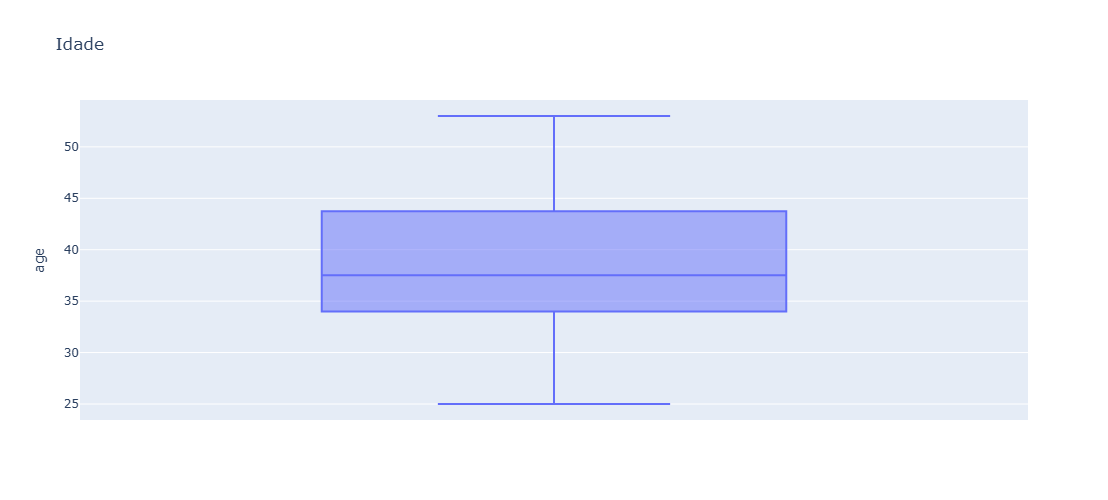

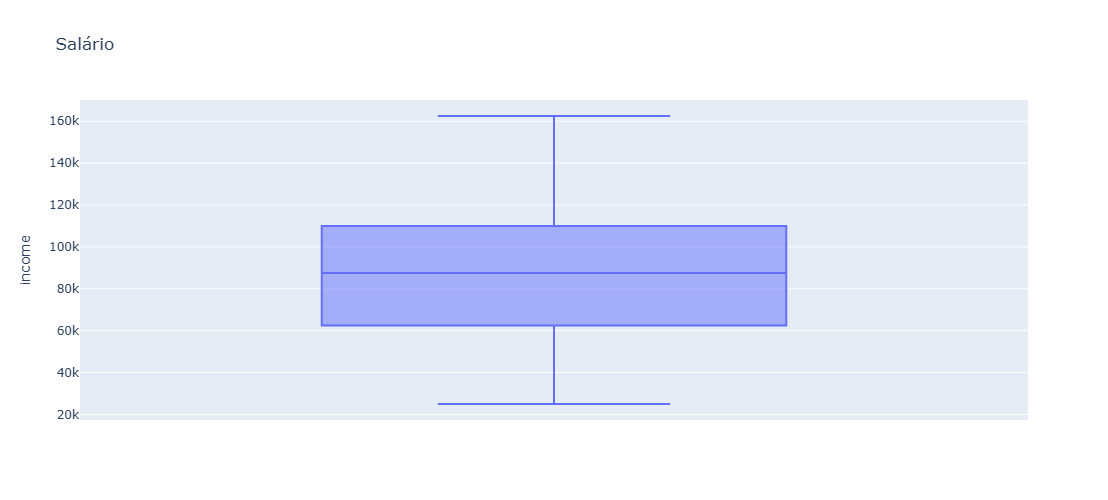

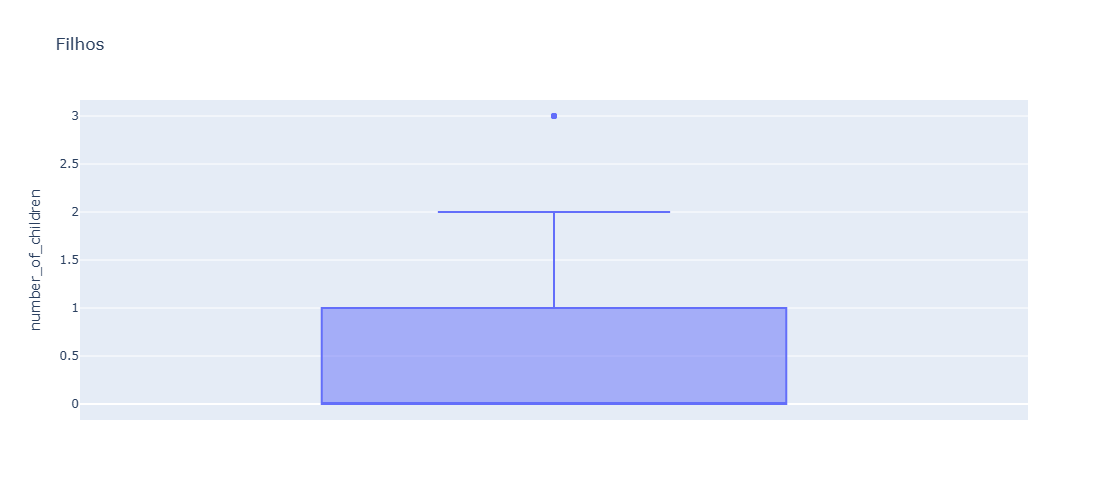

In [74]:
fig = px.box(df, y='age', title='Idade')
fig.update_layout(width=800, height=500)
fig.show()

fig = px.box(df, y='income', title='Salário')
fig.update_layout(width=800, height=500)
fig.show()


fig = px.box(df, y='number_of_children', title='Filhos')
fig.update_layout(width=800, height=500)
fig.show()
#sim, 4 registros com 3 filhos removidos porque eram poucos.

In [75]:
(df['number_of_children'] == 3).sum()

np.int64(4)

In [76]:
df = df[df['number_of_children'] != 3]

In [77]:
(df['number_of_children'] == 3).sum()

np.int64(0)

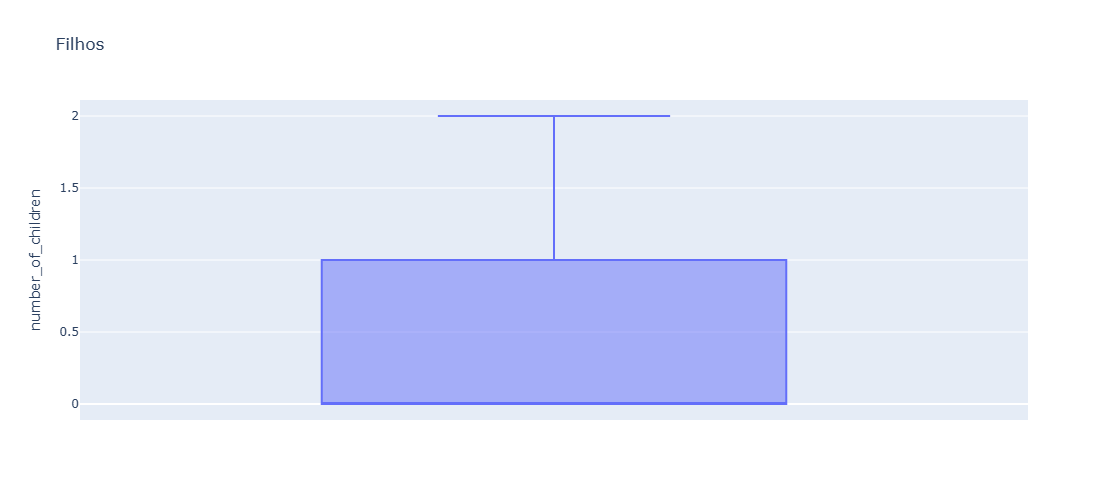

count    115.000000
mean       0.565217
std        0.785063
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        2.000000
Name: number_of_children, dtype: float64

In [78]:
fig = px.box(df, y='number_of_children', title='Filhos')
fig.update_layout(width=800, height=500)
fig.show()
df['number_of_children'].describe()

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

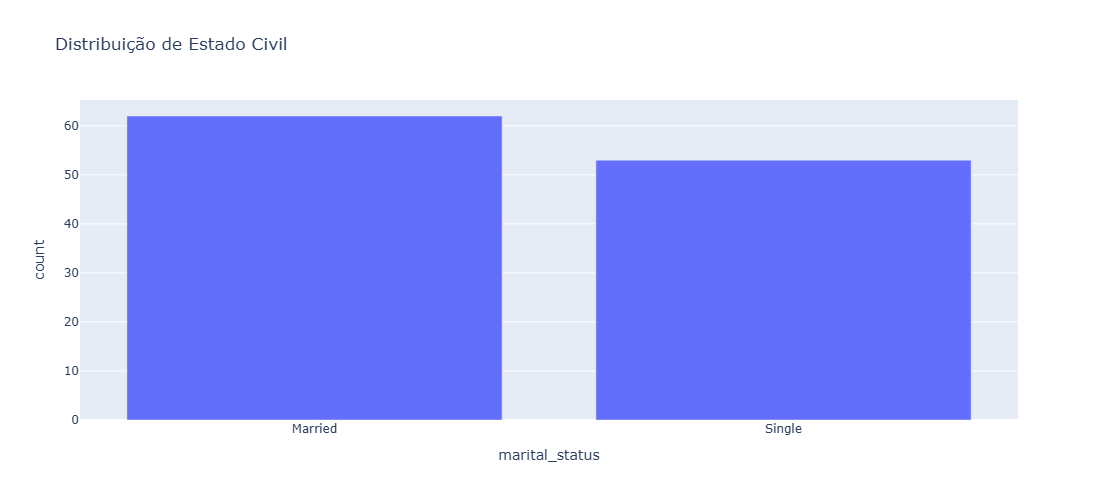

In [79]:
df_count = df['marital_status'].value_counts().reset_index()
df_count.columns = ['marital_status', 'count']
fig = px.bar(
    df_count,
    x='marital_status',
    y='count',
    title='Distribuição de Estado Civil'
)
fig.update_layout(width=800, height=500)

fig.show()


In [80]:
df['marital_status'].value_counts()


marital_status
Married    62
Single     53
Name: count, dtype: int64

In [81]:
df['marital_status'].value_counts(normalize=True) * 100

marital_status
Married    53.913043
Single     46.086957
Name: proportion, dtype: float64

Não há forte predominância de nenhum estado civil. 

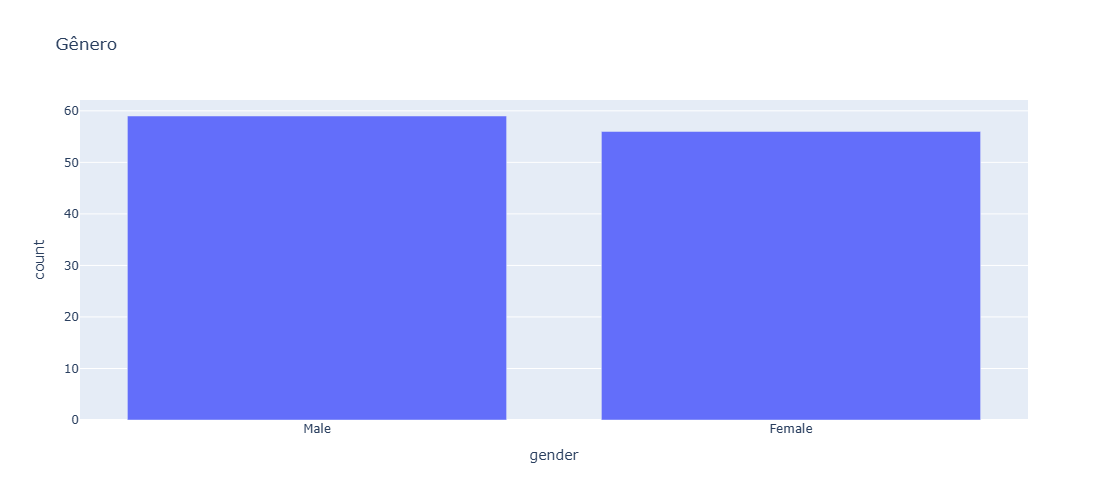

In [82]:
df_count = df['gender'].value_counts().reset_index()
df_count.columns = ['gender', 'count']
fig = px.bar(
    df_count,
    x='gender',
    y='count',
    title='Gênero'
)
fig.update_layout(width=800, height=500)

fig.show()

In [83]:
df['gender'].value_counts(normalize=True) * 100

gender
Male      51.304348
Female    48.695652
Name: proportion, dtype: float64

Também não há forte predominância de nenhum gênero. 

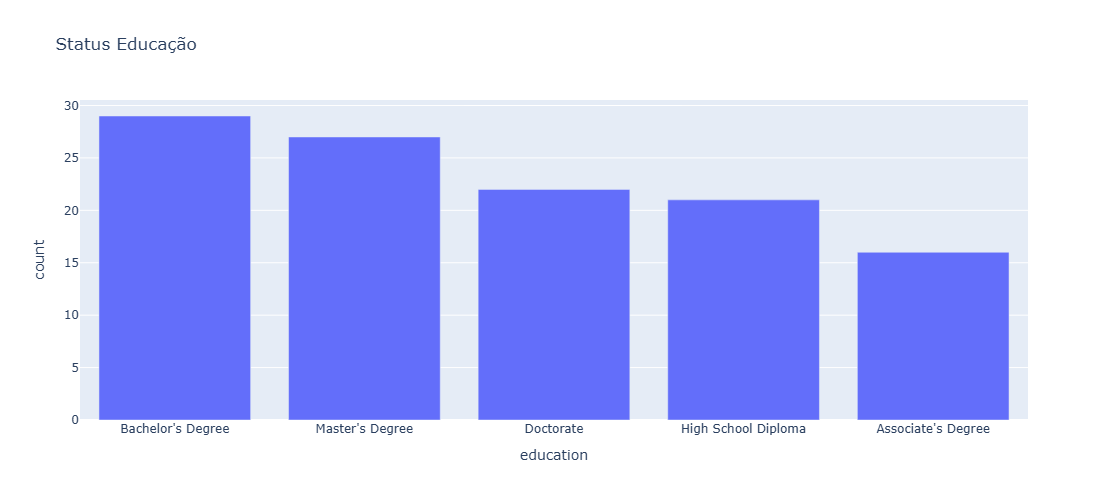

In [84]:
df_count = df['education'].value_counts().reset_index()
df_count.columns = ['education', 'count']
fig = px.bar(
    df_count,
    x='education',
    y='count',
    title='Status Educação'
)
fig.update_layout(width=800, height=500)

fig.show()

In [85]:
df['education'].value_counts(normalize=True) * 100

education
Bachelor's Degree      25.217391
Master's Degree        23.478261
Doctorate              19.130435
High School Diploma    18.260870
Associate's Degree     13.913043
Name: proportion, dtype: float64

A maior parcela das pessoas possui nível superior ou mais (68%), sendo o nível superior completo a faixa de formação predominante com aproximadamente 28%. 

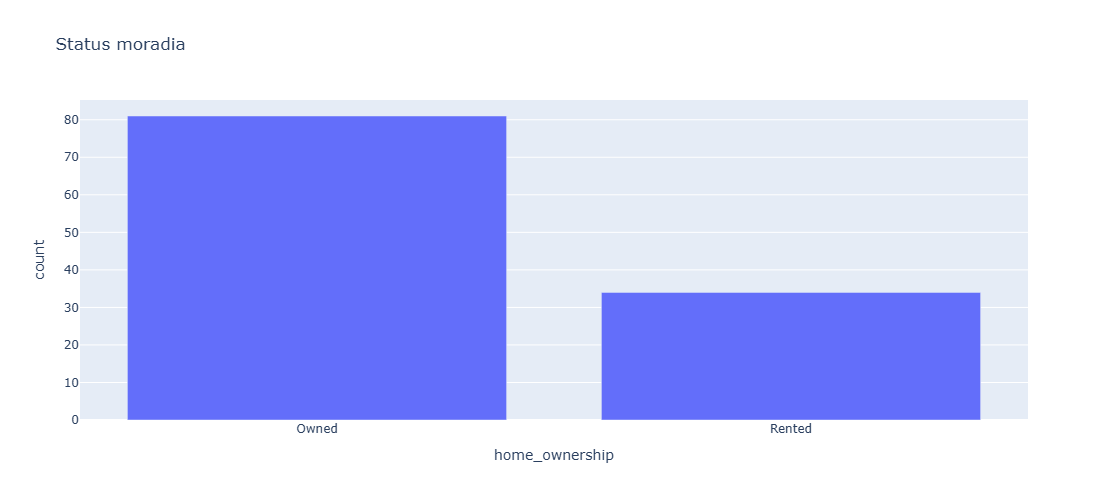

In [86]:
df_count = df['home_ownership'].value_counts().reset_index()
df_count.columns = ['home_ownership', 'count']
fig = px.bar(
    df_count,
    x='home_ownership',
    y='count',
    title='Status moradia'
)
fig.update_layout(width=800, height=500)

fig.show()

In [87]:
df['home_ownership'].value_counts(normalize=True) * 100

home_ownership
Owned     70.434783
Rented    29.565217
Name: proportion, dtype: float64

Mais de 70% da amostra é dona da própria casa o que sugere uma relativa estabilidade e constância.

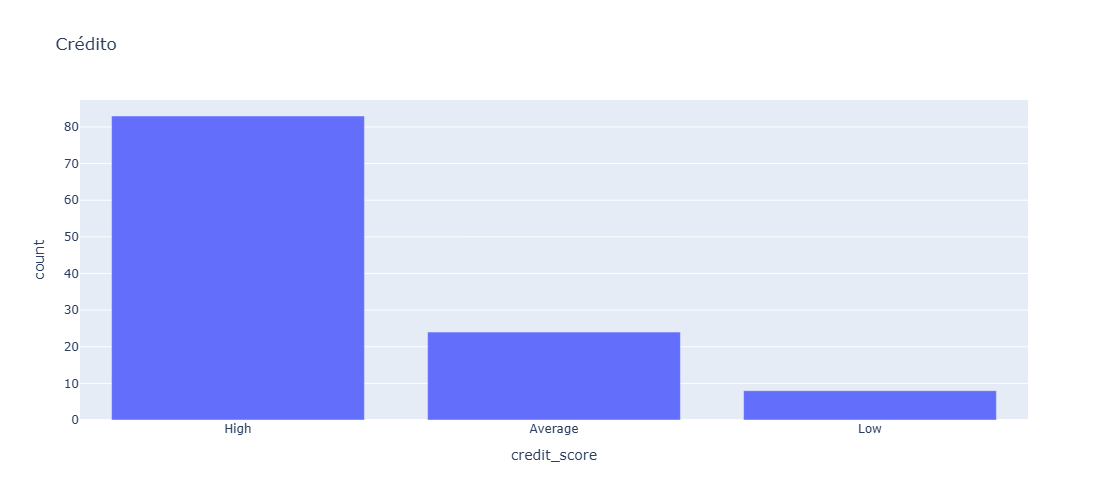

In [88]:
df_count = df['credit_score'].value_counts().reset_index()
df_count.columns = ['credit_score', 'count']
fig = px.bar(
    df_count,
    x='credit_score',
    y='count',
    title='Crédito'
)
fig.update_layout(width=800, height=500)

fig.show()

In [89]:
df['credit_score'].value_counts(normalize=True) * 100

credit_score
High       72.173913
Average    20.869565
Low         6.956522
Name: proportion, dtype: float64

Poucos clientes possuem baixo score de crédito, sendo a maior parte deles financeiramente equilibrados.

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil? Os dados sugerem que sim, já que a distribuiçõ de idade varia com o estado civil, os clientes casados tendem a apresentar concentração acima de 40 anos.
*   Qual a relação entre o score de crédito e o nível de escolaridade? os dados mostram que nas faixas de maior escolaridade estão concentrados os níveis mais altos de crédito e nas faixas de menor escolaridade scores mais baixo.
*  O salário parece influenciar na idade? os dados sugerem que sim, já que nas faixas de menor idade estão concentrados os menores salários. Os slários tendem a "subir" até os 50 anos e depois apresenta pequena queda.
* O salário parece influenciar no Score de Crédito? Aparentemente não muito, já que os grupos estão sobrepostos e existem lientes com diferentes faixas de renda nas 3 categorias de score.
* Clientes com casa própria tendem a ter um score mais alto? Os dados mais uma vez sugerem que sim, pois os cliente donos dos próprios imóveis possuem o score mais alto.



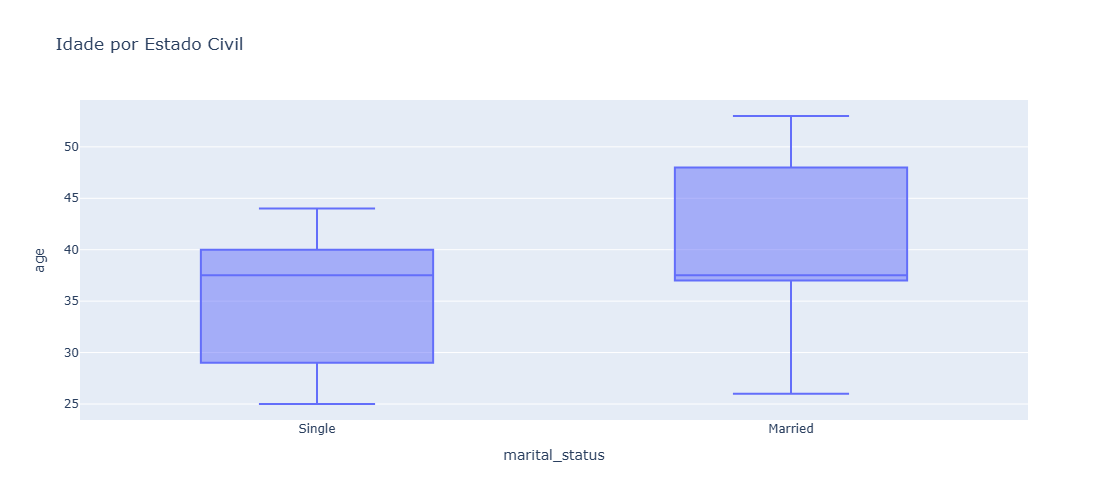

In [90]:
fig = px.box(
    df,
    x='marital_status',
    y='age',
    title='Idade por Estado Civil'
)

fig.update_layout(width=800, height=500)
fig.show()

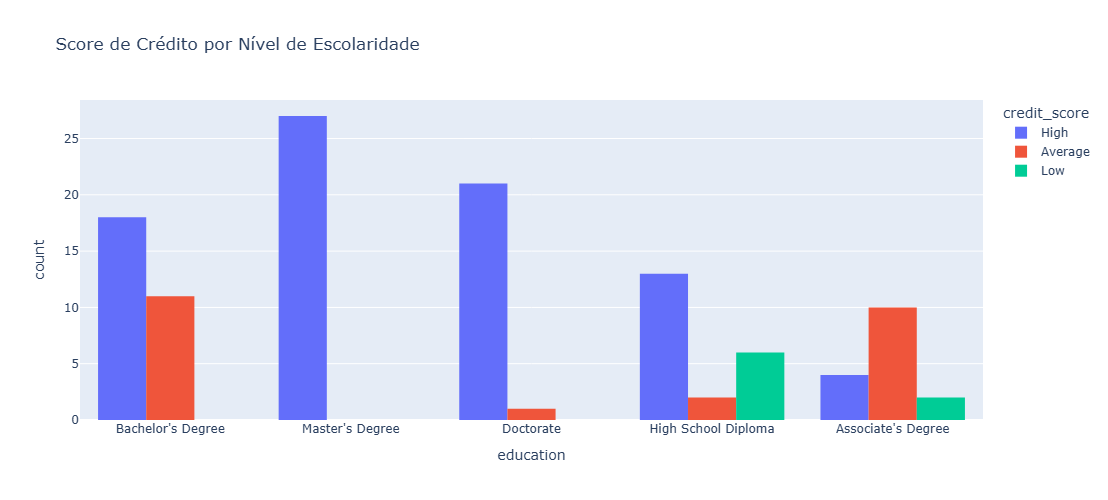

In [91]:
fig = px.histogram(
    df,
    x='education',
    color='credit_score',
    barmode='group',
    title='Score de Crédito por Nível de Escolaridade'
)
fig.update_layout(width=800, height=500)
fig.show()

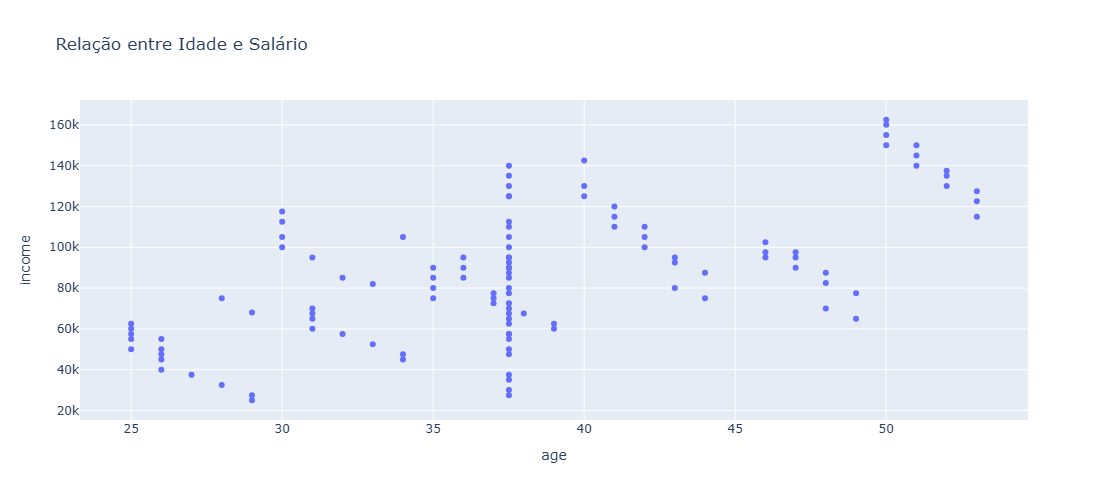

In [92]:
fig = px.scatter(
    df,
    x='age',
    y='income',
    title='Relação entre Idade e Salário'
)
fig.update_layout(width=800, height=500)

fig.show()

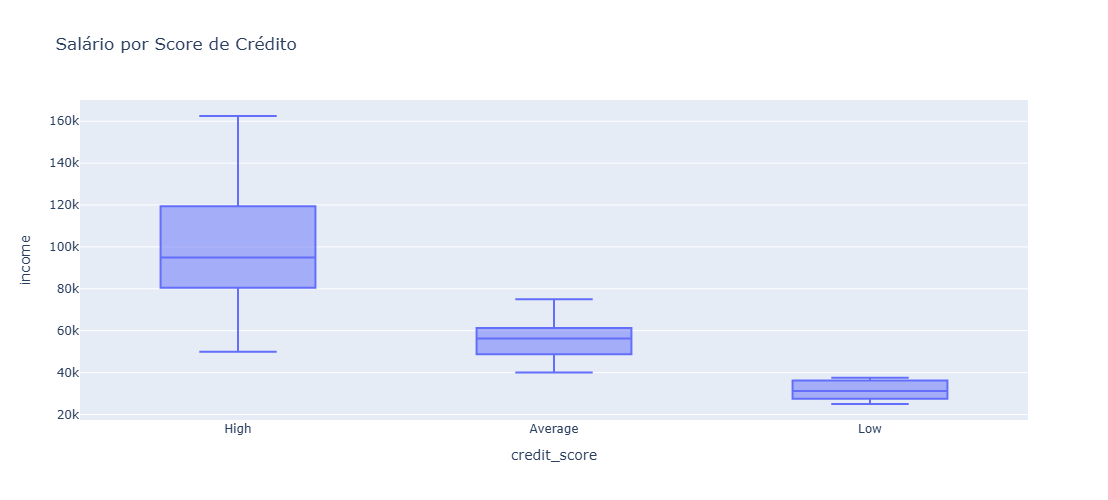

In [93]:

fig = px.box(
    df,
    x='credit_score',
    y='income',
    title='Salário por Score de Crédito'
)
fig.update_layout(width=800, height=500)
fig.show()

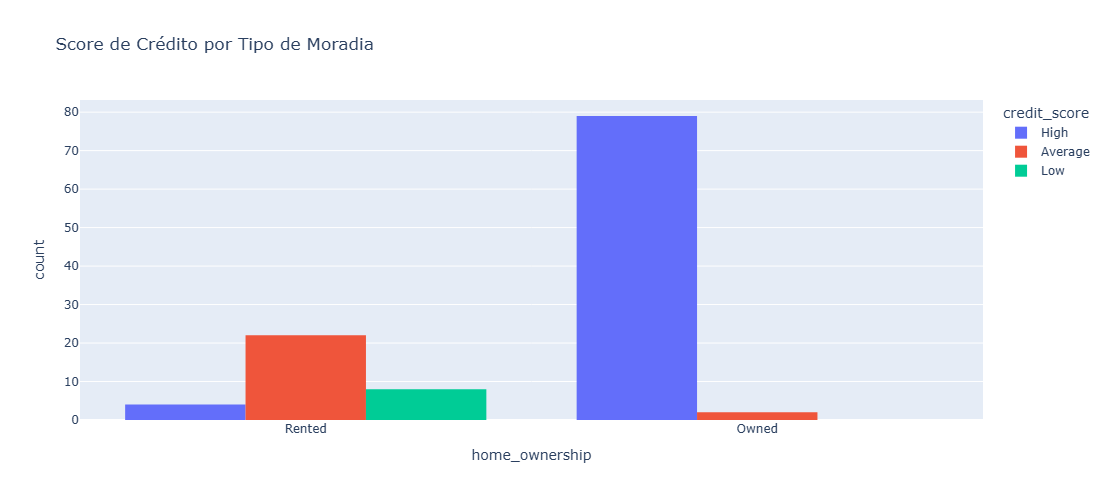

In [94]:
fig = px.histogram(
    df,
    x='home_ownership',
    color='credit_score',
    barmode='group',
    title='Score de Crédito por Tipo de Moradia'
)
fig.update_layout(width=800, height=500)

fig.show()

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.
 <br>
 Clientes com maior renda têm mais filhos? Os dados não sugerem nenhuma tendencia nesse sentido já que encontramos 0,1 e 2 filhos em todas as faixas de renda.
  <br>
 Pessoas com filhos têm score diferente? Aparentemente sim, pessoas com 1/2 filhos possuem score alto de crédito e nenhum registro de baixo. Talvez porque apresentem um melhor planejamento financeiro e estabilidade.
  <br>
 Idade influencia o score de crédito? os dados sugerem que sim poque pessoas mais velhas tendem a possuir score mais alto talvez pelo histórico mais longo que permite mapear melhor os comportamentos.
 

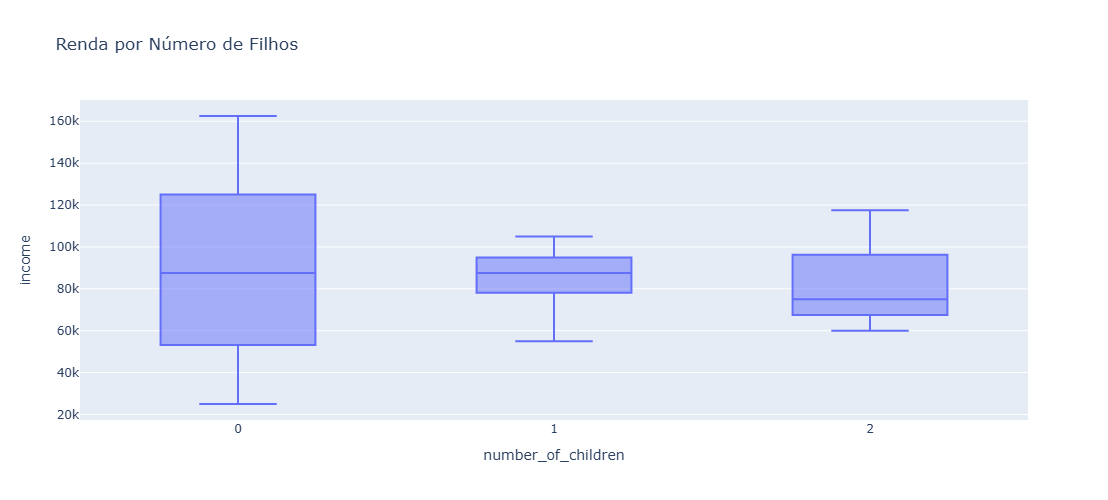

In [95]:
fig = px.box(
    df,
    x='number_of_children',
    y='income',
    title='Renda por Número de Filhos'
)
fig.update_layout(width=800, height=500)
fig.show()

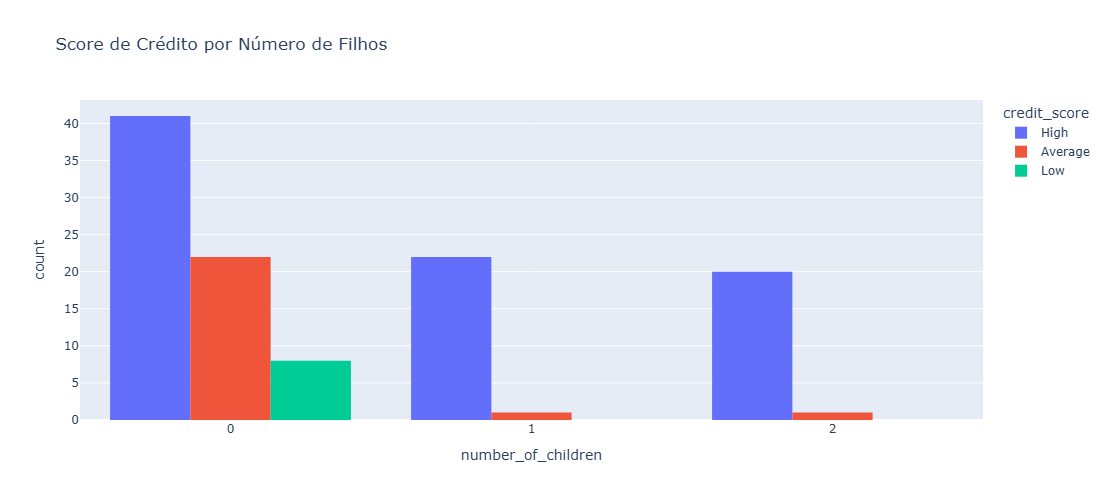

In [96]:
fig = px.histogram(
    df,
    x='number_of_children',
    color='credit_score',
    barmode='group',
    title='Score de Crédito por Número de Filhos'
)
fig.update_layout(width=800, height=500)


fig.show()

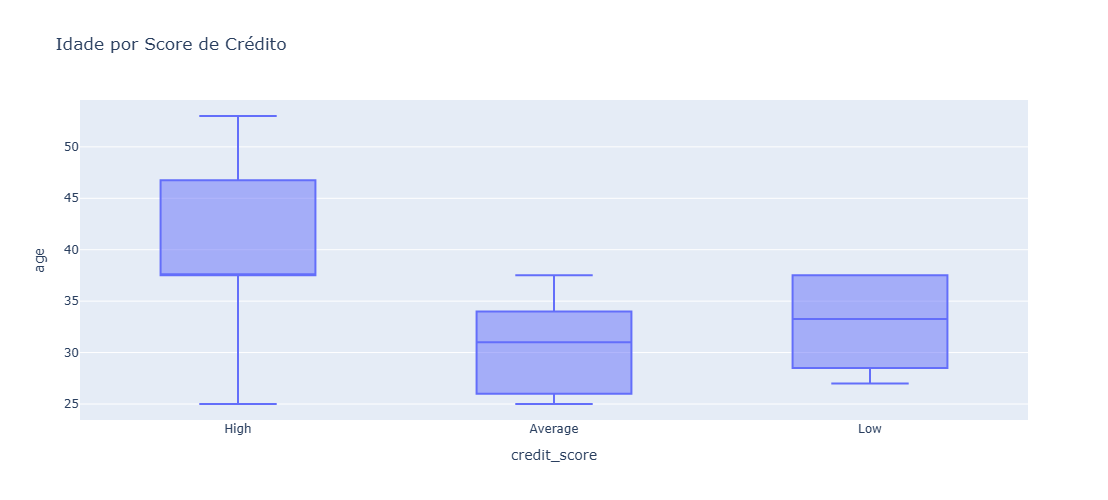

In [97]:
fig = px.box(
    df,
    x='credit_score',
    y='age',
    title='Idade por Score de Crédito'
)

fig.update_layout(width=800, height=500)
fig.show()

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

In [98]:
df.select_dtypes(include=['number']).corr()

,age,income,number_of_children
age,1.000000,0.615532,-0.062963
income,0.615532,1.000000,-0.076310
number_of_children,-0.062963,-0.076310,1.000000


**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.** <br> sim, mas apenas idade e salário (0.61) talvez porque pessoas mais velhas nesse conjunto de dados tiveram mais tempo para estudar, ampliar sua formação e obter melhores salários.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [99]:
#transforma as ategoricas p fazer correlação de td
#transformando as colunas categoricas
print(df.columns)
colunas_credit = ['gender', 'marital_status', 'education', 'home_ownership']
df = pd.get_dummies(df, columns = colunas_credit, drop_first=True) #aplicando o one hot, pois não há ordem e já removendo com drop_first
df.head(10)

Index(['age', 'gender', 'income', 'education', 'marital_status',
       'number_of_children', 'home_ownership', 'credit_score'],
      dtype='str')


,age,income,number_of_children,credit_score,gender_Male,marital_status_Single,education_Bachelor's Degree,education_Doctorate,education_High School Diploma,education_Master's Degree,home_ownership_Rented
0,25.000000,50000.0,0,High,False,True,True,False,False,False,True
1,30.000000,100000.0,2,High,True,False,False,False,False,True,False
2,35.000000,75000.0,1,High,False,False,False,True,False,False,False
3,40.000000,125000.0,0,High,True,True,False,False,True,False,False
5,50.000000,150000.0,0,High,True,False,False,False,False,True,False
6,26.000000,40000.0,0,Average,False,True,False,False,False,False,True
7,31.000000,60000.0,0,Average,True,True,True,False,False,False,True
8,37.507692,80000.0,2,High,False,False,False,False,False,True,False
9,37.507692,105000.0,0,High,True,True,False,True,False,False,False
10,37.507692,90000.0,1,High,False,False,False,False,True,False,False


In [100]:
df.dtypes #é preciso verificar se converteu para inteiro-caso contr´rio ele não faz a correlação

age                              float64
income                           float64
number_of_children                 int64
credit_score                         str
gender_Male                         bool
marital_status_Single               bool
education_Bachelor's Degree         bool
education_Doctorate                 bool
education_High School Diploma       bool
education_Master's Degree           bool
home_ownership_Rented               bool
dtype: object

In [101]:
for column in df.columns:
    if df[column].dtype =='bool':
        df[column] = df[column].astype(int)

In [102]:
df.dtypes

age                              float64
income                           float64
number_of_children                 int64
credit_score                         str
gender_Male                        int64
marital_status_Single              int64
education_Bachelor's Degree        int64
education_Doctorate                int64
education_High School Diploma      int64
education_Master's Degree          int64
home_ownership_Rented              int64
dtype: object

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

idade e:<br>
salário 0.61 (talvez mais idade para esse grupo tenha ampliado a possibilidade de expandir a formação)
education bachelors degree -0.23, 
education doctorate 0.16,
marital status -0.42(talvez mais idade para esse grupo seja uma fase mais atrelada a esse tipo de compromisso),
home ownership -0.59(talvez mais idade para esse grupo tenha ampliado a possibilidade de expandir a formação e também ampliado os recursos e ganhos para comprar a casa),
credit score high 0.58(talvez todos os fatores acima e ainda um histórico para esse grupo ter como base para avaliar a concessão de crédito)
<br>

salário e:<br>
idade 0.61,
marital status -0.43,
education master's degree 0.30,
home ownership -0.66,
credit score high 0.70,
credit score low -0.46(talvez para esse grupo a faixa de renda influencie diretamento o quanto de crédito será fornecido).
<br>

number_of_children e:<br>
marital status -0.67 (talvez para esse grupo a opção pelo casamento esteja ligada aos filhos),
gender male -0.49,
home ownership -0.44(talvez para esse grupo a opção pelo casamento esteja ligada aos filhos e a compra da casa para família),
credit score high 0.37 (talvez todos os fatores acima e ainda um histórico para esse grupo ter como base para avaliar a concessão de crédito)
<br>

gender male e:<br>
income 0.55
number_of_children -0.50
<br>

marital status_single e:<br>
number_of_children -0.67(talvez para esse grupo a opção pelo casamento esteja ligada aos filhos),
home ownership 0.66,
credit score high -0.59,
income -0.43,
age -0.42,
<br>

home ownership (rented) e:<br>
credit score high -0.87,
income -0.66,
age -0.60,
marital status 0.66
<br>

credit score high e:<br> 
income 0.70,
home ownership -0.87,
age 0.58,
marital status -0.59 
<br> Aparentemente a variável alvo score de crédito está altamente ligada ao salário, compra da casa, idade e estado civil, sendo esses fatores também interligados.

In [103]:
#seu código aqui

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [104]:
x = df.drop('credit_score', axis = 1)
y = df['credit_score']
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.25, random_state =42)


In [105]:
print('tamanho', X_train.shape)

tamanho (86, 10)


In [106]:
print(X_train.columns)

Index(['age', 'income', 'number_of_children', 'gender_Male',
       'marital_status_Single', 'education_Bachelor's Degree',
       'education_Doctorate', 'education_High School Diploma',
       'education_Master's Degree', 'home_ownership_Rented'],
      dtype='str')


In [107]:
print('tamanho', X_test.shape)

tamanho (29, 10)


In [108]:
print('tamanho', Y_train.shape)

tamanho (86,)


In [109]:
print('tamanho', Y_test.shape)

tamanho (29,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

credit_score
High       72.173913
Average    20.869565
Low         6.956522
Name: proportion, dtype: float64


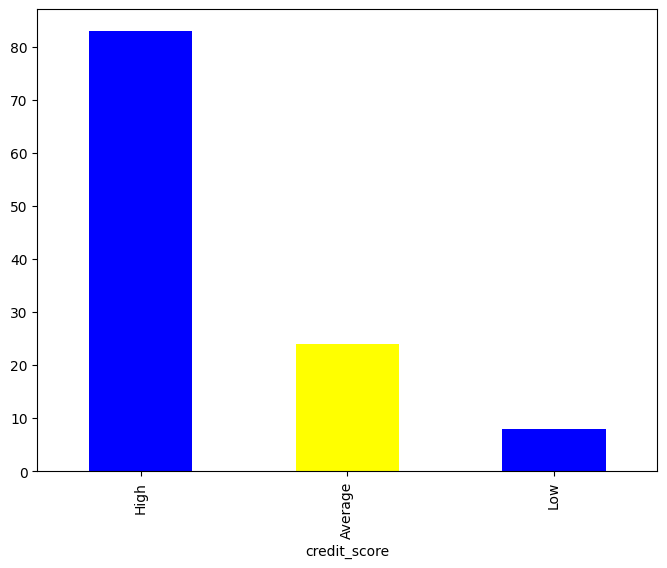

In [110]:
credit = df['credit_score'].value_counts()
plt.figure(figsize=(8,6))
credit.plot(kind='bar', color = ['blue', 'yellow'])
print((df['credit_score'].value_counts(normalize = True) *100))
                                   

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

sim, está desbalanceado porque a base teste possui 73,10 % High ainda que o modelo não estivesse bom ele acertaria 73% "chutando" high.

In [111]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_balanced, Y_train_balanced = ros.fit_resample(X_train, Y_train)
print('Distribuição')
print(Y_train_balanced.value_counts())
print('Balanço em y_train')
print(Y_train.value_counts())
X_train_balanced.to_csv('X_train_balanced.csv', index=False)
Y_train_balanced.to_csv('Y_train_balanced.csv', index=False)
Y_test.to_csv('Y_test.csv', index=False)
X_test.to_csv('X_test.csv', index=False)

Distribuição
credit_score
High       61
Average    61
Low        61
Name: count, dtype: int64
Balanço em y_train
credit_score
High       61
Average    20
Low         5
Name: count, dtype: int64


Como só tinham 5 exemplos de low optei por ampliar/ duplicar o número de registros porque assim o modelo não vai ignorar a categoria, mas também por outro lado ele pode overfitting.

In [112]:
print('Antes:', X_train.shape)
print('Depois:', X_train_balanced.shape) #o x aumentou junto com o y

Antes: (86, 10)
Depois: (183, 10)


In [113]:
print(len(X_train))
print(len(X_train_balanced))

86
183


In [114]:
!pip install imbalanced-learn

In [115]:
import sys
print(sys.executable)

C:\Users\Regina\AppData\Local\Programs\Python\Python313\python.exe


In [116]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: C:\Users\Regina\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [117]:
print(Y_train.value_counts())

credit_score
High       61
Average    20
Low         5
Name: count, dtype: int64
